# Transformer Architecture Overview

We already know basic about self attention and Transformer in previous notebook. In this notebook we will learn in details about Transformer step by step.


The **Transformer** is a deep learning architecture introduced in the paper *“Attention is All You Need”* (2017).  It has become the backbone of modern NLP models like **BERT, GPT, T5** and beyond. Transformers remove the need for recurrence (RNNs, LSTMs, GRUs) and instead use **self-attention** to process sequences in parallel, capturing long-range dependencies efficiently. Here is the encoder decoder architecture mentioned in the paper ***Attention is all you need.*** Don't worry about it in details, we will go step by step.


<div align="center">

  [![attent.png](https://i.postimg.cc/Bb7Sm55V/attent.png)](https://postimg.cc/D4s3ZXMr)

*Source: [ Attention is all you need original paper](https://arxiv.org/abs/1706.03762)*
</div>





Before diving into details let's summarize the overall workflow. **Training a Transformer** begins with a large dataset of paired examples, such as source sentences and their corresponding target sentences in **translation tasks**. During training, the model does not see just a single sentence but instead learns from **millions of such pairs**. Each input sentence is first **tokenized** and converted into vectors **using embeddings**, with **positional encodings added to preserve word order**. The encoder then processes this input. Inside each encoder layer, the **self-attention mechanism** allows every token to compare itself with all other tokens by computing query, key, and value vectors. These comparisons produce **attention scores** that highlight which words are **most relevant** for understanding the current word. The output of this attention step is then passed through a **feed-forward network**, which independently transforms each token’s representation. Stacking multiple encoder layers gradually refines the input into rich **contextual embeddings** that capture both local and long-range relationships.

The decoder is trained simultaneously to generate the **target sentence one word at a time**. It begins with the ground-truth target sequence shifted by one position, so the model learns to predict the next word given the previous ones. Each decoder layer first applies **masked self-attention**, which ensures that a token can only attend to earlier tokens and not peek ahead. After this, the decoder performs **encoder–decoder attention**, where the **queries** from the decoder interact with the **keys and values from the encoder output**. This step allows the decoder to focus on the most relevant parts of the input sequence when generating each word. Finally, the result passes through a feed-forward network, refining the representation before moving deeper into the decoder stack. At the top, a linear layer followed by a softmax converts the decoder’s output into a probability distribution over the vocabulary.

Training is driven by comparing these predicted probabilities with the actual target words using cross-entropy loss. Through backpropagation and optimization (commonly with Adam), **the model’s parameters in the embeddings, attention layers, and feed-forward networks are updated**. This process repeats across many sentences and epochs, gradually teaching the Transformer to align input and output sequences. In essence, the encoder learns to build powerful contextual representations of the source text, while the decoder learns to use those representations, along with its own past outputs, to generate the correct target sequence step by step.



##**Encoder Decoder Component**
Now first we need to know about encoder and decoder components. In the figure below we have encoder block, decoder block and a connection between them.

<div align='center'>

[![trans-enc.png](https://i.postimg.cc/8Cy9YkML/trans-enc.png)](https://postimg.cc/sBhTQrn2)
*figure: Encoder-Decoder Components*
</div>

We see Nx in the main architecture right. It is nothing but a details of  one encoder and decoder block forget about the details just remember we have stack of encoder in encoding component and stack of decoders in decoding component. Transformer architecture mentioned in the paper has total six each encoders and decoders. In our encoding and decoding component there are total six encoders and decoders



Till now, we know that input goes through encoding component of six stacked encoder and it process some output and then it's goes through stacked of decoders and gives us output.

Now, we are learning here what actually happening inside encoder and decoder.

[![enc-dec-f.png](https://i.postimg.cc/q7bDwkCS/enc-dec-f.png)](https://postimg.cc/nsm1cf2G)

In the Transformer architecture, both the **encoder** and **decoder** are built from stacked layers, but their components serve slightly different purposes.

On the **encoder side**, each layer mainly consists of two sub-components: **self-attention** and a **feed-forward network**.  
- The **self-attention mechanism** enables each token in the input sequence to look at (attend to) every other token. This helps the model capture contextual relationships, such as long-range dependencies, without relying on sequential processing like RNNs.  
- The **feed-forward network** then processes the contextualized embeddings independently for each token, adding non-linearity and further transforming the representation into a richer vector space.  

On the **decoder side** (right), the structure is slightly more complex. Each layer has **three sub-components**: **self-attention**, **encoder-decoder attention**, and a **feed-forward network**.  
- The **self-attention** in the decoder works similarly to the encoder but with a masking mechanism, ensuring the model only looks at past tokens during training (so predictions for the next word don’t "cheat" by seeing the future).  
- The **encoder-decoder attention** is what connects the decoder to the encoder. Here, the decoder queries the encoder’s output representations to gather relevant information about the input sequence. For example, when translating, this lets the decoder focus on the right source words when generating each target word.  
- Finally, the **feed-forward network** processes the attended representations and refines them before passing them deeper into the decoder stack.  





## Attention in a Transformer Network

The attention mechanism in a Transformer Network can be best described with the concept of query, key and value. The key, value, query concepts come from retrieval systems.
When we search for a video on youtube, we are querying the the best matched videos in the database. The search engine maps the typed query with a set of keys(which can be video title, descriptions etc.) associated with the candidate videos in the database, then it will return us the best matched videos(values).

<!-- <img src="https://docs.google.com/uc?export=download&id=19j3_kV0Dcjll6HNg6xyLc6UQZVf_xsPD" >
 <figcaption> Figure 3: Query, Keys and Values intuition. </figcation> -->
<img src="https://i.postimg.cc/L8hWz0kM/image.png" >
 <figcaption> Figure 3: Query, Keys and Values intuition. </figcation>



In a Transformer network, each word have it's corresponding key, query and a value associated with it. Key, query and value are all vectors and are learnt during the training process. It can be thought of as separating a word vector into three separate vectors.


<!-- <img src="https://docs.google.com/uc?export=download&id=1UZUDUGTFO4B0JLmoKOo4Q9iwDlrMd2lx" > -->
<img src="https://i.postimg.cc/ZnT70fY2/image.png" >
 <figcaption> Figure 4: Query, Key and Value as vectors in a Transformer network. </figcation>


The attention can be described as a weighted sum of the values, where the weight assigned to each value is computed as a similarity score between the query with the corresponding key.

<!-- <img src="https://docs.google.com/uc?export=download&id=1-0XueRCk1R6e44YJZVORUrWzJf6Vv2Vl" >
 <figcaption> Figure 5: Attention as a mapping between query and a set of key-value pairs. </figcation> -->
<img src="https://i.postimg.cc/gktSkqCt/image.png" >
 <figcaption> Figure 5: Attention as a mapping between query and a set of key-value pairs. </figcation>


This explains the attention mechanism. The best matched key with the query have higher similarity score and thus it's corresponding value is weighted with much importance and it means that this value should get much of the attention for the given query. The final attention score is the sum the of all of the weighted values.


Bahdanau attention(link to paper or earlier chapter is a special case of a Transformer attention where a word have shared vectors for key, query and a value. In case of Bahdanau attention mechanism the same embedded vector (which is the hidden state of a LSTM network) is used as key, query and value.


## *We will learn in details about self attention in next notebook.*


## Self-Attention
Self-attention is the heart of the Transformer. Instead of LSTM, GRU blocks transformer uses self-attention. It allows each token in the sequence to **attend to every other token**, helping the model capture relationships like subject–verb agreement or long-range dependencies.

### How It Works:
For each input token embedding $(x_i$), we compute three vectors:
- **Query (Q)**: What am I looking for?
- **Key (K)**: What information do I offer?
- **Value (V)**: What actual content do I carry?

These are obtained by multiplying the embedding with learned matrices:

$
Q = xW_Q, \quad K = xW_K, \quad V = xW_V
$

where $
W_Q, \quad W_K, \quad W_V
$ are trainable parameters, we will discuss in details in self-attention notebook.
### Attention Scores:
To see how much token $(i$) should attend to token $(j$), we compute:

$
\text{Score}(i,j) = \frac{Q_i \cdot K_j}{\sqrt{d_k}}
$

- The dot product measures similarity (relevance).
- Scaling by $(\sqrt{d_k}$) prevents large values.
- A softmax is applied to turn scores into probabilities.

The attention output for token $(i$) is a weighted combination of all values. This means each token representation becomes a **contextualized version** of itself, enriched by the tokens it attends to. Once we calculate the **attention scores** using queries and keys, we need to decide how much each token should attend to others.

- First, apply a **Softmax** to convert raw scores into probabilities:
$
\alpha_{ij} = \frac{\exp(\text{Score}(i,j))}{\sum_k \exp(\text{Score}(i,k))}
$

- These probabilities $(\alpha_{ij}$) represent **how strongly token \(i\) should focus on token \(j\)**.

- Finally, each token creates a new representation by taking a **weighted sum of the Value vectors (V)**:
$
z_i = \sum_j \alpha_{ij} V_j
$

This $z_i$ is similar to $
\text{Attention}(Q_i, K, V) = \sum_j \text{Softmax}(\text{Score}(i,j)) \cdot V_j
$

After this step, each token is no longer just itself — it has been **contextualized**:
- “The” knows it modifies *book*  
- “book” knows it is described as *amazing*  
- “was” links subject and predicate  
- “amazing” knows it describes *book*  

Each word embedding is now enriched with **context from the whole sentence**.

## Feed Forward Neural Network (FFN)
After self-attention mixes information across tokens, we need a way to **transform** these representations into more powerful features. The contextual embeddings $(z_i$) from self-attention are then passed into the **two-layer feed-forward network**, applied independently to each token.


For each token separately:
$
h_i = W_2 \cdot \sigma(W_1 z_i + b_1) + b_2
$

- $(z_i$): contextual embedding from attention  
- $(W_1, W_2$): weight matrices  
- $(b_1, b_2$): biases  
- $(\sigma$): non-linear activation (ReLU or GELU)  

 Unlike attention, the FFN does **not mix tokens**. Each token is transformed independently, adding **non-linearity** and allowing the model to capture more complex features.

### Key Points:
- **Token-wise**: Unlike self-attention, FFN does not mix tokens. Each token is processed independently.
- **Non-linearity**: Adds non-linear transformations, allowing the model to learn more complex patterns.
- **Expansion and compression**: Typically, the hidden dimension is larger (e.g., 512 → 2048 → 512), giving the network more expressive power.

[![ffnn.png](https://i.postimg.cc/yxNMk5Zf/ffnn.png)](https://postimg.cc/dkzHf5nd)

## Flow in an Encoder Layer
1. Input tokens → **Self-Attention** → contextualized embeddings  
2. Contextual embeddings → **FFN** → refined token representations  
3. Residual connections + LayerNorm keep training stable

We mention here residual conneection and LayerNorm we need to explain.

###Residual Connections + Layer Normalization

When training very deep models like Transformers, two challenges often appear:  
1. **Vanishing/Exploding Gradients** – signals become too weak or too strong as they pass through many layers.  
2. **Training Instability** – outputs of different layers can vary in scale, making optimization harder.  

To solve this, Transformers use **Residual Connections** and **Layer Normalization** together.  

#### 1. Residual Connections (Skip Connections)  
A residual connection simply **adds the original input of a layer back to its output**:

$
\text{Output} = \text{Layer}(x) + x
$

- Creates a **shortcut path** for gradients during backpropagation.  
- Prevents the network from “forgetting” the original information.  
- If a deeper layer struggles to learn, the model can still fall back on the identity mapping.  

 Think of it like a **safety net** — even if the new transformation isn’t perfect, the original information is preserved.  



#### 2. Layer Normalization  
After adding the residual, the model applies **LayerNorm**, which normalizes the output across features:

$
\text{LayerNorm}(x) = \frac{x - \mu}{\sigma} \cdot \gamma + \beta
$

- $(\mu, \sigma$) = mean and standard deviation of the features  
- $(\gamma, \beta$) = learnable scaling and shifting parameters  

This ensures that:  
- The output has a **stable distribution** (mean ≈ 0, variance ≈ 1).  
- Training becomes smoother because inputs to the next layer always stay on a predictable scale.  

 Imagine training a group of students: **LayerNorm is like grading on a curve**, so no one’s score is too extreme.  


#### 3. Combined Effect  
- **Residual connection** = preserves original knowledge + helps gradient flow.  
- **LayerNorm** = stabilizes scale of outputs + prevents internal covariate shift.  
- Together → make training **stable, faster, and more accurate**, even in very deep Transformer networks.  


 **In short:**  
- Residual = *"Don’t lose the original message."*  
- LayerNorm = *"Keep signals balanced and stable."*


**Summary**  
- **Self-Attention** = lets tokens "talk to each other" and learn context.  
- **Feed Forward Network** = lets each token "think independently" and transform its meaning.  
Together, they make the Transformer both **context-aware** and **expressive**.


## Encoder-Only Transformers: Applications and Working

Encoder-only Transformers, such as **BERT** or **Vision Transformers (ViT)**, are primarily designed for tasks where the goal is to **understand and represent input data** rather than generate new sequences. During processing, the encoder takes raw input tokens (words, patches, or signals), converts them into embeddings, and enriches them through layers of **self-attention** and **feed-forward networks**. The result is a set of **contextualized embeddings**, where each token’s vector not only represents its standalone meaning but also its relationship with every other token in the sequence. This contextual representation is the key reason why encoder outputs are so powerful.

The embeddings produced by the encoder can be directly used for various applications. In **text classification**, these embeddings allow the model to distinguish whether a review is positive or negative, since the meaning of words like *“good”* or *“bad”* are understood in their sentence context. For **named entity recognition (NER)**, contextual embeddings help identify whether a word like *“Apple”* refers to a fruit or a company. In **semantic similarity** tasks, embeddings of two different sentences can be compared, and if their contextual meaning aligns, the model recognizes them as paraphrases. Encoders are also widely applied in **search engines** and **semantic retrieval**, where both queries and documents are transformed into embeddings, and their similarity is computed to return the most relevant results. Beyond NLP, **Vision Transformers (ViTs)** use the same encoder mechanism on image patches, enabling applications such as image classification, medical imaging, and image retrieval.

In short, the encoder’s ability to produce **rich contextual embeddings** bridges the gap between raw input and meaningful task-specific outputs. These embeddings capture not only the token itself but its **intended meaning within context**, which is why encoder-only architectures excel in understanding-focused applications.


## *We discuss about encoder till now, let's move to decoder section.*

## Decoder-Only Transformers

While encoder-only models focus on **understanding input**, decoder-only models are designed for **generating sequences**. These models take previously generated tokens (or a prompt) and predict the **next token** step by step, making them ideal for tasks that involve producing text, code, or other sequences. Famous decoder-only models include **GPT (Generative Pretrained Transformer)** series, **LLaMA**, and **Gemma**.

The working of a decoder-only Transformer relies on **masked self-attention**. Unlike the encoder, where each token can attend to all tokens in the input, the decoder must follow the rule of **causality**: a token can only attend to itself and the tokens before it, never to the future. This masking ensures that when predicting the next word in a sentence, the model does not “cheat” by looking ahead. For example, in the phrase *“The cat sat on the”*, the model can only use information up to *“the”* when predicting the next likely token *“mat”*. After attention has contextualized the tokens, a **feed-forward network** further refines these representations, and the final output layer (usually a softmax) predicts the probability distribution over the entire vocabulary for the next token.

Decoder-only models shine in **text generation tasks**. They are used in **language modeling**, **chatbots**, **creative writing**, **summarization**, **story or code generation**, and **auto-completion systems**. Beyond text, they are also applied in **protein sequence generation**, **music generation**, and other structured output domains. In all these applications, the key strength of decoder-only models is their ability to generate coherent, contextually relevant, and creative sequences by predicting one token at a time and feeding it back into the model for the next step.

 **In short**: Decoder-only Transformers are generative engines. They start with a prompt, use masked self-attention to maintain causal order, and generate outputs token by token. This makes them the backbone of modern **large language models (LLMs)** like ChatGPT, which excel at producing human-like text.




### Masked Self Attention

Masked attention is used at the decoder side of the transformer just after the embedding component. Masked attention is very similar to the self-attention with few minor differences. With a sequential model like RNNs, the decoder receives one word at each time step so the decoder would be unfamiliar with the next word during both training and testing. However in the transformer, the decoder process all the words in a sentence simultaneously. This mechanism allows the decoder to compute attention result by looking at the future words which are not predicted/generated yet. So decoder must be trained in such a way that it doesn't know the future word and hence it couldn't cheat and don't learn to look at future words because at test time we don't have the future words. This is not an issue with the sequential model as they process one word at each time step. Therefore, the decoder is allowed to attend the earlier positions; not the future positions. So we simulate the same scenario of testing time for the training time. We can do this by applying a special masking called a subsequent mask.


<!-- <img src="https://docs.google.com/uc?export=download&id=1liU6S7J9bsA1KcjTPzXNvpBqcWzTw6M7" >
<figcaption>Figure 7: Masking the input at the decoder side to prevent access of future words by words at initial positions. <figcaption> -->
<img src="https://i.postimg.cc/0NRCbtcn/image.png" >
<figcaption>Figure 7: Masking the input at the decoder side to prevent access of future words by words at initial positions. <figcaption>

**Note**: It is assumed that the students already know the concepts of tokenization and padding in earlier chapters. Students should keep in mind that the illustration only show the `<start>` token and it is assumed that they get the intuition that there are extra paddings upto `MAX_SEQUENCE_LENGTH` and `<end>` token as well at the end of the sentence.

<!-- <figure>
<center>
<img src="https://docs.google.com/uc?export=download&id=1_wmYdJDpl-oilTHT08FaHVU6Ij1VWJOp" alt="input to decoder">
<figcaption>Figure 19: Masking the input at the decoder side to prevent access of future words by words at initial positions. <figcaption>
</center>
</figure>

 -->



Moreover,during training we wrap up sentence with start and end token.
i.e, For sentence, I love being a vegeterian

$
\begin{matrix}
\color {blue}{Input:} & <start> & I & love & being& a & vegeterian\\
\color{blue}{Label:} & I & love & begin & a & vegeterian & <end>
\end{matrix}
$

And the label above should be masked as discussed above. The input to the decoder will be:

<figure>
<center>


<p>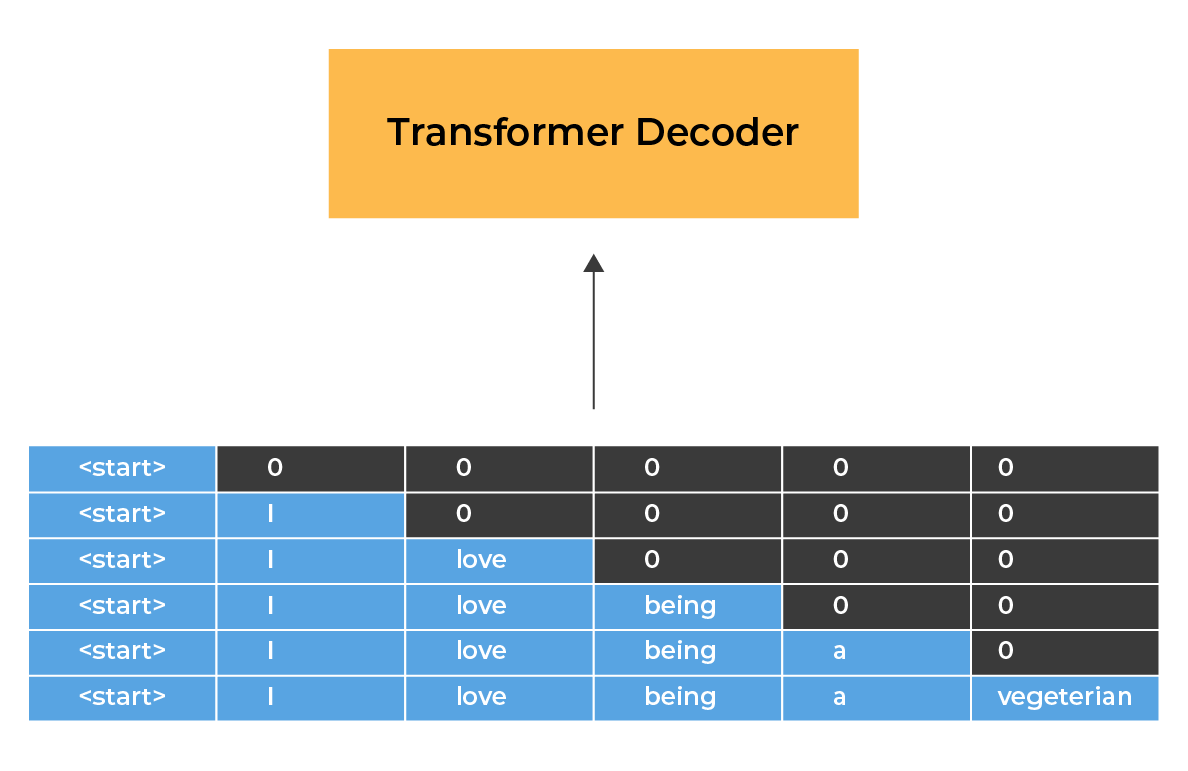</p>
<figcaption>Figure 19: Masking the input at the decoder side to prevent access of future words by words at initial positions. <figcaption>
</center>
</figure>





### Encoder Decoder Attention

The overall process in the Transformer network is shown with the gif below. The colored circles represents the attention. The encoder and decoder layers are three layered. In the encoder part we apply self attention in all those three layers. In the Decoder part, we first mask the inputs and apply self attention, followed by encoder-decoder attention in all three layers. The output of the Linear plus softmax after the attentions gives the next predicted word after the previously predicted words.



<!-- <img src="https://drive.google.com/uc?export=view&id=16KVRCKlor3VFs1ZtfiRhvZB2O-fwjBL0">
 <figcaption> Figure 8: Overall process in a Transformer </figcation> -->

<img src="https://i.postimg.cc/DyRrMjkh/download.gif">

<div align='center'>
 <figcaption> Figure 8: Overall process in a Transformer </figcation>
 </div>

### *We will explain Multihead attention, Feed Forward Neural NEtwork and Output Layer in **Multihead Attention** notebook.*

## Key Takeways
* Transformer models get rid of sequential models such as RNNs and LSTMs and solely depend on attention mechanisms.

* The use of positional embedding helps to structure the sequential model in a transformer network without the need for recurrent neural networks.

* Self attention helps the model to achieve parallelization in the Transformer network. It helps to reduce the computational complexity per layer. And it helps to learn the long-range dependencies in the network.

* Masking prevents the model from accessing the future words.


##**Resources**

https://jalammar.github.io/illustrated-transformer/  
https://www.turing.com/kb/brief-introduction-to-transformers-and-their-power
